<a href="https://colab.research.google.com/github/baranimurugan53-gif/CODSOFT/blob/main/CODSOFT_Movie__Rating_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving IMDb Movies India.csv to IMDb Movies India.csv
Dataset Shape: (15509, 10)

First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Act

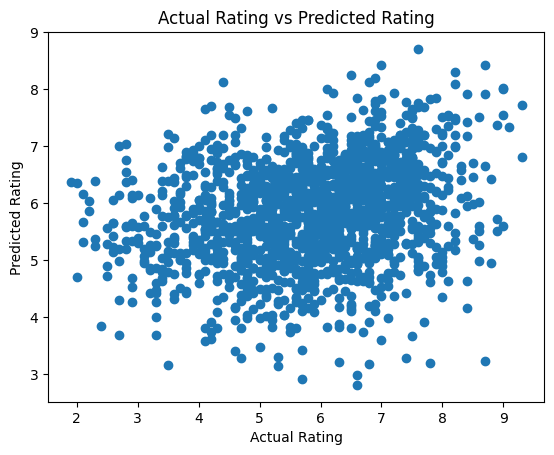

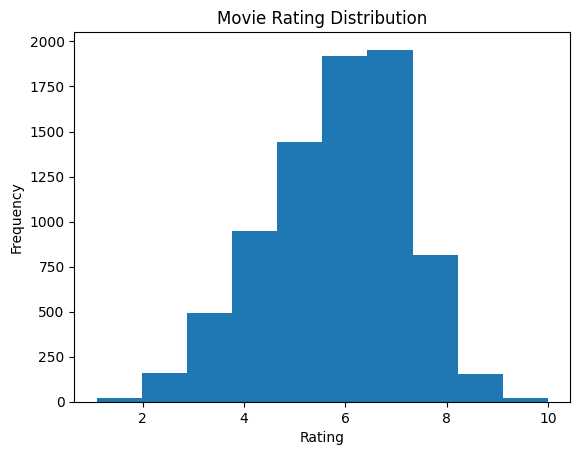

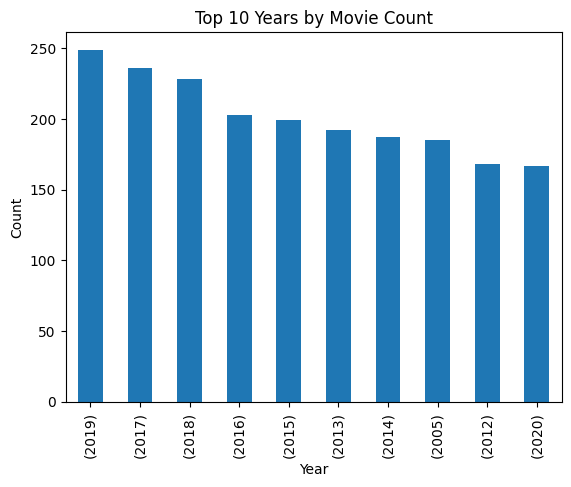

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

df = df.dropna(subset=["Rating"])

df["Genre"] = df["Genre"].fillna("Unknown")
df["Director"] = df["Director"].fillna("Unknown")

le = LabelEncoder()

df["Genre"] = le.fit_transform(df["Genre"])
df["Director"] = le.fit_transform(df["Director"])

X = df[["Genre", "Director"]]
y = df["Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nR2 Score:", r2_score(y_test, y_pred))
print("\nMean Absolute Error:", mean_absolute_error(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.title("Actual Rating vs Predicted Rating")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.show()

df["Rating"].plot(kind="hist")
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.show()

df["Year"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Years by Movie Count")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()